# Week 3 - DSV: The Cleaning Sprint

## Handling Missing Values and Outlier Detection

**Dataset:** Spotify Songs

**Topics:** Missing Value Imputation, Boxplots, Z-score Outlier Detection

## 1. Import Libraries

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
!pip install kagglehub

## 2. Load Dataset

In [35]:
import kagglehub

path = kagglehub.dataset_download("nikitatkachenko/19332-spotify-songs")

print(path)

C:\Users\Tejus\.cache\kagglehub\datasets\nikitatkachenko\19332-spotify-songs\versions\2


In [36]:
import os

print(os.listdir(path))

['19332_Spotify_Songs.csv']


In [37]:
df = pd.read_csv(
    os.path.join(path, "19332_Spotify_Songs.csv"),
    encoding="latin1"
)

C:\Users\Tejus\AppData\Local\Temp\ipykernel_13632\648217527.py:1: DtypeWarning: Columns (9,11) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(


## 3. Dataset Overview

In [38]:
df.head()

,id,artists,available_markets,disc_number,duration_ms.x,explicit,href,is_local,name,popularity,...,instrumentalness,liveness,valence,tempo,type.y,uri.y,track_href,analysis_url,duration_ms.y,time_signature
0,000xQL6tZNLJzIrtIgxqSl,https://api.spotify.com/v1/artists/5ZsFI1h6hId...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,188490,FALSE,https://api.spotify.com/v1/tracks/000xQL6tZNLJ...,FALSE,Still Got Time (feat. PARTYNEXTDOOR),63,...,0.000000,0.0852,0.524,120.963,audio_features,spotify:track:000xQL6tZNLJzIrtIgxqSl,https://api.spotify.com/v1/tracks/000xQL6tZNLJ...,https://api.spotify.com/v1/audio-analysis/000x...,188491.0,4.0
1,001UkMQHw4zXfFNdKpwXAF,https://api.spotify.com/v1/artists/0XKOBt59crn...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,191053,FALSE,https://api.spotify.com/v1/tracks/001UkMQHw4zX...,FALSE,Brand New Man - with Luke Combs,68,...,0.000079,0.2900,0.562,127.061,audio_features,spotify:track:001UkMQHw4zXfFNdKpwXAF,https://api.spotify.com/v1/tracks/001UkMQHw4zX...,https://api.spotify.com/v1/audio-analysis/001U...,191053.0,4.0
2,003FTlCpBTM4eSqYSWPv4H,https://api.spotify.com/v1/artists/3vAaWhdBR38...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,233266,FALSE,https://api.spotify.com/v1/tracks/003FTlCpBTM4...,FALSE,"Swing, Swing",67,...,0.128000,0.0385,0.318,127.947,audio_features,spotify:track:003FTlCpBTM4eSqYSWPv4H,https://api.spotify.com/v1/tracks/003FTlCpBTM4...,https://api.spotify.com/v1/audio-analysis/003F...,233267.0,4.0
3,003vvx7Niy0yvhvHt4a68B,https://api.spotify.com/v1/artists/0C0XlULifJt...,"AD, AE, AL, AR, AT, AU, BA, BE, BG, BH, BO, BR...",1,222973,FALSE,https://api.spotify.com/v1/tracks/003vvx7Niy0y...,FALSE,Mr. Brightside,80,...,0.000000,0.0995,0.236,148.033,audio_features,spotify:track:003vvx7Niy0yvhvHt4a68B,https://api.spotify.com/v1/tracks/003vvx7Niy0y...,https://api.spotify.com/v1/audio-analysis/003v...,222973.0,4.0
4,005lwxGU1tms6HGELIcUv9,https://api.spotify.com/v1/artists/6jJ0s89eD6G...,"CA, JP, US",1,179640,FALSE,https://api.spotify.com/v1/tracks/005lwxGU1tms...,FALSE,I Kissed A Girl,68,...,0.000000,0.1320,0.696,129.996,audio_features,spotify:track:005lwxGU1tms6HGELIcUv9,https://api.spotify.com/v1/tracks/005lwxGU1tms...,https://api.spotify.com/v1/audio-analysis/005l...,179640.0,4.0


In [39]:
df.shape

(19335, 46)

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19335 entries, 0 to 19334
Data columns (total 46 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id                            19333 non-null  object 
 1   artists                       19335 non-null  object 
 2   available_markets             19335 non-null  object 
 3   disc_number                   19335 non-null  int64  
 4   duration_ms.x                 19335 non-null  object 
 5   explicit                      19335 non-null  object 
 6   href                          19335 non-null  object 
 7   is_local                      19335 non-null  object 
 8   name                          19333 non-null  object 
 9   popularity                    19334 non-null  object 
 10  preview_url                   11811 non-null  object 
 11  track_number                  19334 non-null  object 
 12  type.x                        19334 non-null  object 
 13  u

## 4. Missing Value Analysis

We identify missing values in the dataset before applying suitable imputation strategies.

In [41]:
df.isnull().sum()

id                                 2
artists                            0
available_markets                  0
disc_number                        0
duration_ms.x                      0
explicit                           0
href                               0
is_local                           0
name                               2
popularity                         1
preview_url                     7524
track_number                       1
type.x                             1
uri.x                              2
album.album_type                   2
album.artists                      2
album.available_markets            2
album.href                         2
album.id                           2
album.images                       2
album.name                         2
album.release_date                 4
album.release_date_precision       4
album.total_tracks                 4
album.type                         4
album.uri                          4
album.external_urls.spotify        7
e

In [42]:
df.isnull().sum().sort_values(ascending=False)

preview_url                     7524
time_signature                     7
acousticness                       7
album.external_urls.spotify        7
external_ids.isrc                  7
external_urls.spotify              7
danceability                       7
energy                             7
key                                7
loudness                           7
mode                               7
speechiness                        7
instrumentalness                   7
liveness                           7
valence                            7
tempo                              7
type.y                             7
uri.y                              7
track_href                         7
analysis_url                       7
duration_ms.y                      7
album.type                         4
album.uri                          4
album.total_tracks                 4
album.release_date                 4
album.release_date_precision       4
id                                 2
a

In [43]:
df.dtypes

id                               object
artists                          object
available_markets                object
disc_number                       int64
duration_ms.x                    object
explicit                         object
href                             object
is_local                         object
name                             object
popularity                       object
preview_url                      object
track_number                     object
type.x                           object
uri.x                            object
album.album_type                 object
album.artists                    object
album.available_markets          object
album.href                       object
album.id                         object
album.images                     object
album.name                       object
album.release_date               object
album.release_date_precision     object
album.total_tracks               object
album.type                       object


In [44]:
numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols].isnull().sum()

disc_number         0
danceability        7
energy              7
key                 7
loudness            7
mode                7
speechiness         7
acousticness        7
instrumentalness    7
liveness            7
valence             7
tempo               7
duration_ms.y       7
time_signature      7
dtype: int64

### Median Imputation

Median imputation was applied to numerical audio features because the median is less affected by extreme values and potential outliers.

In [45]:
df_original = df.copy()

In [46]:
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

In [47]:
df[numeric_cols].isnull().sum()

disc_number         0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
duration_ms.y       0
time_signature      0
dtype: int64

## 6. Outlier Detection using Boxplots

Boxplots are used to visually identify potential outliers in the numerical audio features.

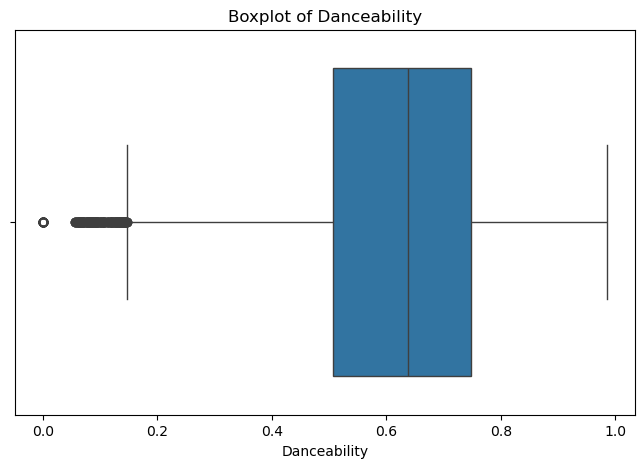

In [48]:
plt.figure(figsize=(8, 5))

sns.boxplot(x=df["danceability"])

plt.title("Boxplot of Danceability")
plt.xlabel("Danceability")
plt.show()

### Observation

The boxplot shows values outside the whiskers that may be potential outliers. These values are not immediately removed because they may represent legitimate Spotify songs.

### Boxplots of Spotify Audio Features

Boxplots are generated for the main numerical audio features to compare their distributions and identify potential outliers.

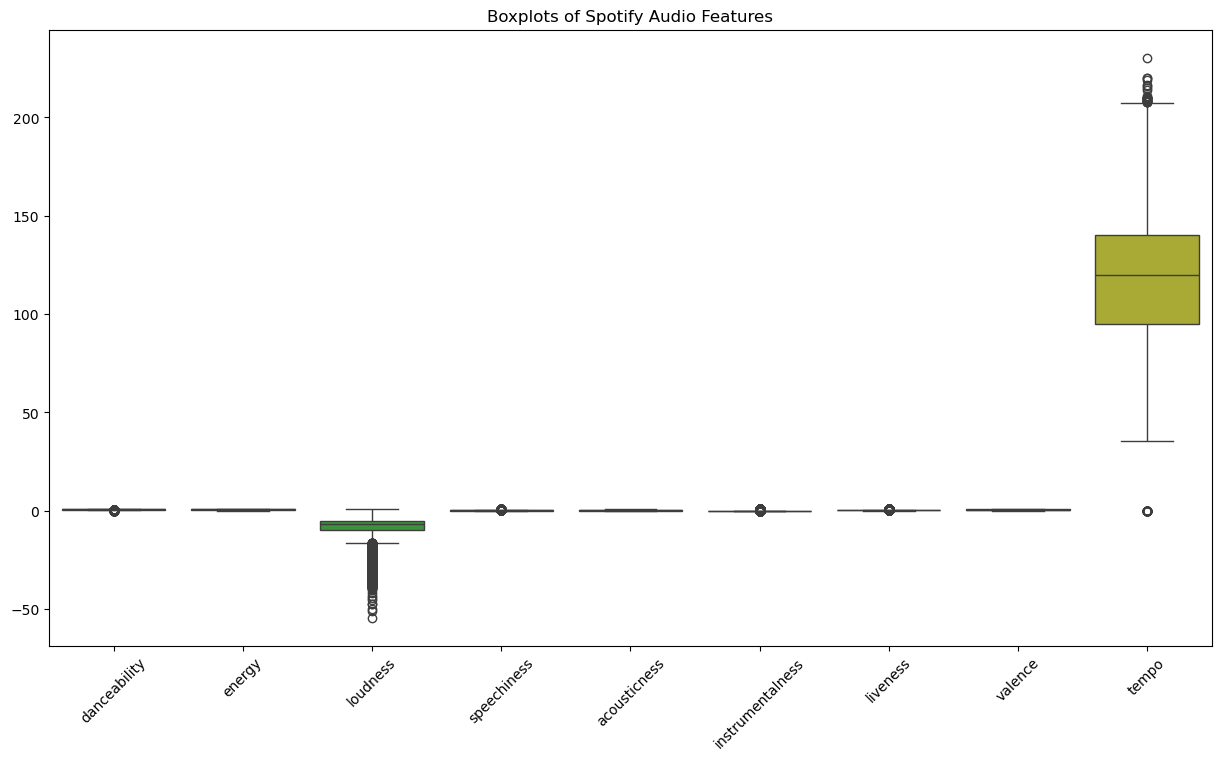

In [49]:
numeric_features = [
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo"
]

plt.figure(figsize=(15, 8))

sns.boxplot(data=df[numeric_features])

plt.xticks(rotation=45)
plt.title("Boxplots of Spotify Audio Features")
plt.show()

In [50]:
from scipy.stats import zscore

In [51]:
z_scores = df[numeric_features].apply(zscore)

In [52]:
outlier_counts = (abs(z_scores) > 3).sum()

print(outlier_counts)

danceability         90
energy                0
loudness            479
speechiness         336
acousticness          0
instrumentalness    886
liveness            524
valence               0
tempo                53
dtype: int64


In [53]:
outlier_percentage = (outlier_counts / len(df)) * 100

print(outlier_percentage.round(2))

danceability        0.47
energy              0.00
loudness            2.48
speechiness         1.74
acousticness        0.00
instrumentalness    4.58
liveness            2.71
valence             0.00
tempo               0.27
dtype: float64


### Observation

Instrumentalness has the highest proportion of potential outliers at 4.58%, followed by liveness at 2.71% and loudness at 2.48%. Energy, acousticness, and valence have no observations with an absolute Z-score greater than 3.

In [54]:
df = df.drop(columns=["preview_url"])

### Mode Imputation

Mode imputation was applied to the categorical column `album.type` because it contains categorical values.

In [55]:
df["album.type"] = df["album.type"].fillna(df["album.type"].mode()[0])

In [56]:
df.isnull().sum().sort_values(ascending=False)

analysis_url                    7
track_href                      7
uri.y                           7
type.y                          7
external_urls.spotify           7
external_ids.isrc               7
album.external_urls.spotify     7
album.total_tracks              4
album.uri                       4
album.release_date_precision    4
album.release_date              4
album.href                      2
album.name                      2
album.images                    2
album.id                        2
id                              2
album.available_markets         2
uri.x                           2
album.artists                   2
name                            2
album.album_type                2
type.x                          1
track_number                    1
popularity                      1
duration_ms.y                   0
available_markets               0
acousticness                    0
disc_number                     0
duration_ms.x                   0
explicit      

In [57]:
cleaning_summary = df[numeric_features].isnull().sum()

print("Missing values after imputation:")
print(cleaning_summary)

Missing values after imputation:
danceability        0
energy              0
loudness            0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
dtype: int64


## 8. Descriptive Statistics

Descriptive statistics are used to understand the central tendency, spread, and range of the Spotify audio features.

In [58]:
df[numeric_features].describe().T

,count,mean,std,min,25%,50%,75%,max
danceability,19335.0,0.616005,0.179831,0.00000,0.50750,0.638000,0.74800,0.985
energy,19335.0,0.584230,0.236855,0.00002,0.44300,0.620000,0.76500,1.000
loudness,19335.0,-8.604707,5.802601,-54.37600,-9.71300,-6.816000,-5.08500,1.060
speechiness,19335.0,0.107324,0.111740,0.00000,0.03820,0.056500,0.12700,0.954
acousticness,19335.0,0.308614,0.321881,0.00000,0.03955,0.175000,0.51700,0.996
instrumentalness,19335.0,0.102127,0.266914,0.00000,0.00000,0.000002,0.00113,1.000
liveness,19335.0,0.182434,0.147081,0.00000,0.09670,0.122000,0.21900,0.993
valence,19335.0,0.491397,0.242718,0.00000,0.30400,0.490000,0.67800,1.000
tempo,19335.0,119.794909,30.966981,0.00000,94.98750,119.894500,140.06750,230.401


In [59]:
print("Original dataset shape:", df_original.shape)
print("Cleaned dataset shape:", df.shape)

Original dataset shape: (19335, 46)
Cleaned dataset shape: (19335, 45)


## 9. Final Cleaning Verification

The cleaned dataset is checked to confirm that missing values in the selected numerical audio features have been successfully handled.

In [60]:
print("Missing values in audio features after cleaning:")
print(df[numeric_features].isnull().sum().sum())

Missing values in audio features after cleaning:
0


### Observation

All selected numerical audio features contain zero missing values after imputation, confirming that the missing-value cleaning process was successful.

## 10. Final Visualization After Cleaning

The final boxplot shows the distributions of the selected Spotify audio features after missing-value imputation.

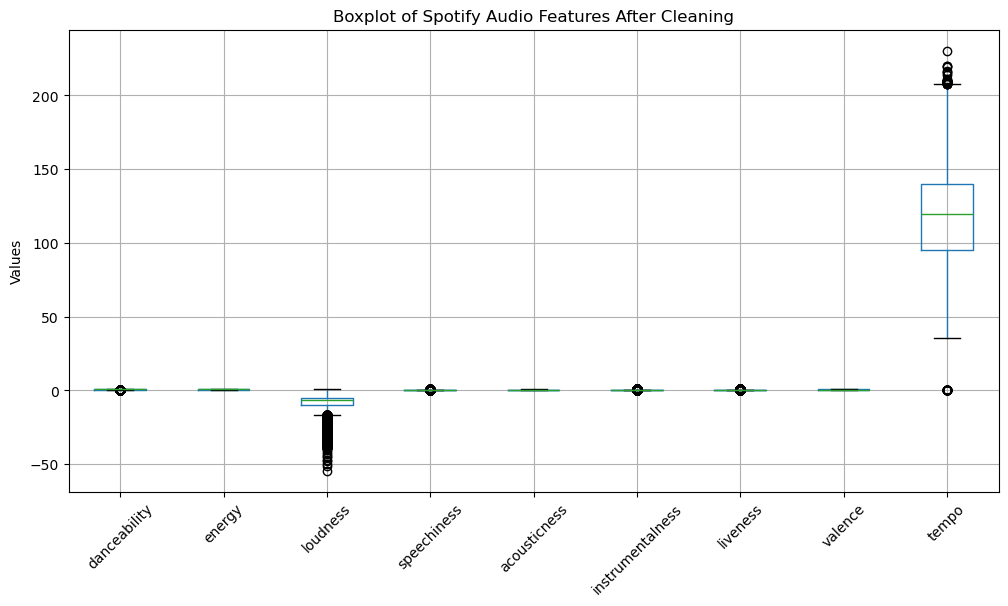

In [61]:
plt.figure(figsize=(12, 6))

df[numeric_features].boxplot()

plt.xticks(rotation=45)
plt.title("Boxplot of Spotify Audio Features After Cleaning")
plt.ylabel("Values")
plt.show()

In [62]:
outlier_summary = pd.DataFrame({
    "Outlier Count": outlier_counts,
    "Outlier Percentage": outlier_percentage.round(2)
})

outlier_summary

,Outlier Count,Outlier Percentage
danceability,90,0.47
energy,0,0.00
loudness,479,2.48
speechiness,336,1.74
acousticness,0,0.00
instrumentalness,886,4.58
liveness,524,2.71
valence,0,0.00
tempo,53,0.27


## 11. Conclusion

The Spotify Songs dataset was cleaned by identifying and handling missing values using suitable imputation strategies. Median imputation was applied to numerical audio features, while mode imputation was used for the categorical column `album.type`. The `preview_url` column was removed because it contained a large proportion of missing values.

Outliers were identified using boxplots and Z-score analysis. Potential outliers were detected using the |Z| > 3 rule and were retained because unusual audio-feature values can represent legitimate songs rather than data errors.

After cleaning, the selected numerical audio features contained no missing values. The analysis also provided an understanding of the distribution and potential outliers present in the Spotify dataset.

In [64]:
df.to_csv("cleaned_dataset.csv", index=False)